# Toronto Street Network Foundation

## tl;dr

Using the bundled Toronto Centreline source, the Phase 1 drivable-street filter retains **49,571 of 64,671** source segments. The resulting direction-aware multigraph contains **35,953 nodes**, **93,144 directed edges**, and **49 weakly connected components**. Its largest component contains **99.54% of nodes**.

These figures describe the current explicit drivable-street definition. They do **not** represent walkability, pedestrian accessibility, or every linear feature in the Centreline dataset.

## Context & Methods

This notebook validates the first reusable project layer: a street graph built from Toronto Centreline intersection IDs. Data cleaning and graph construction live in `src/cleaning.py` and `src/network.py`; the notebook is a reader-facing verification artifact.

### Key assumptions

- Intersection IDs define graph connectivity.
- Edge lengths are measured after projection to EPSG:26917.
- Parallel street segments are preserved in a `MultiDiGraph`.
- One-way descriptions determine permitted travel direction.
- Rivers, railways, shorelines, hydro lines, trails, walkways, ferry routes, busways, pending features, and geostatistical lines are excluded from this Phase 1 drivable graph.
- Self-loop segments are retained and reported rather than silently removed.

## Data

### 1. Load and prepare the source

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import networkx as nx
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cleaning import DRIVABLE_STREET_FEATURES, prepare_street_edges
from src.network import build_street_graph, summarize_network

data_path = project_root / "data/raw/Centreline/toronto_centerline.shp"
street_edges, cleaning_report = prepare_street_edges(data_path)

display(pd.Series(asdict(cleaning_report), name="value").to_frame())

,value
source_rows,64671
retained_rows,49571
excluded_rows,15100
target_crs,EPSG:26917
invalid_geometry_rows,0
duplicate_centerline_ids,0
missing_from_intersection_ids,0
missing_to_intersection_ids,0
self_loop_segments,92
left_address_range_coverage_pct,63.08


### 2. Confirm the retained feature population

In [2]:
feature_counts = (
    street_edges["feature_desc"]
    .value_counts()
    .rename_axis("feature_desc")
    .reset_index(name="segment_count")
)

assert set(feature_counts["feature_desc"]) == set(DRIVABLE_STREET_FEATURES)
display(feature_counts)

,feature_desc,segment_count
0,Local,24893
1,Collector,6383
2,Major Arterial,5890
3,Laneway,4156
4,Minor Arterial,3573
5,Other,2100
6,Expressway,1188
7,Expressway Ramp,1132
8,Major Arterial Ramp,172
9,Access Road,57


## Results

### 3. Build the direction-aware multigraph

In [3]:
street_graph = build_street_graph(street_edges)
network_report = summarize_network(street_graph)

display(pd.Series(asdict(network_report), name="value").to_frame())

,value
nodes,35953.000
directed_edges,93144.000
source_segments,49571.000
weakly_connected_components,49.000
largest_component_nodes,35788.000
largest_component_pct,99.540
self_loop_source_segments,92.000
one_way_source_segments,5953.000
total_source_length_km,6388.516
node_ids_with_endpoint_spread_over_1m,1.000


### 4. Verify topology and source-segment accounting

In [4]:
component_sizes = sorted(
    (len(component) for component in nx.weakly_connected_components(street_graph)),
    reverse=True,
)

checks = {
    "all_retained_segments_represented": network_report.source_segments == len(street_edges),
    "length_reconciles_with_cleaning_report": abs(
        network_report.total_source_length_km - cleaning_report.total_length_km
    ) < 0.01,
    "largest_component_matches_report": component_sizes[0] == network_report.largest_component_nodes,
    "no_invalid_geometries": cleaning_report.invalid_geometry_rows == 0,
    "no_duplicate_centerline_ids": cleaning_report.duplicate_centerline_ids == 0,
    "no_missing_intersection_ids": (
        cleaning_report.missing_from_intersection_ids == 0
        and cleaning_report.missing_to_intersection_ids == 0
    ),
}

assert all(checks.values()), checks
display(pd.Series(checks, name="passed").to_frame())
display(pd.Series(component_sizes[:10], name="nodes").rename_axis("component_rank").to_frame())

,passed
all_retained_segments_represented,True
length_reconciles_with_cleaning_report,True
largest_component_matches_report,True
no_invalid_geometries,True
no_duplicate_centerline_ids,True
no_missing_intersection_ids,True


,nodes
component_rank,
0,35788
1,17
2,13
3,10
4,6
5,5
6,5
7,5
8,4


### 5. Inspect travel-direction coverage

In [5]:
direction_summary = (
    street_edges["oneway_desc"]
    .value_counts(dropna=False)
    .rename_axis("oneway_description")
    .reset_index(name="source_segments")
)
display(direction_summary)

longest_segments = street_edges.nlargest(10, "length_m")[
    ["centerline_id", "street_label", "feature_desc", "length_m"]
].copy()
longest_segments["length_m"] = longest_segments["length_m"].round(1)
display(longest_segments)

,oneway_description,source_segments
0,Not One-Way,43618
1,Follow-Digitization,3618
2,Against-Digitization,2335


,centerline_id,street_label,feature_desc,length_m
37986,60022347,Highway 401,Expressway,1878.8
10451,20037572,Highway 401,Expressway,1877.7
44098,7240751,Highway 400,Expressway,1765.3
44477,60048054,Norfinch Dr,Minor Arterial,1655.4
38001,60022539,Highway 401,Expressway,1539.1
36314,60000936,Highway 401,Expressway,1538.1
36939,30137869,Midwest Rd,Collector,1524.9
44096,444632,Highway 400,Expressway,1471.4
8453,439456,Highway 401,Expressway,1457.1
38550,10367893,Toryork Dr,Collector,1451.4


## Takeaways

- The filtered source population is internally consistent: all 49,571 retained segments appear in the graph and source length reconciles across cleaning and network summaries.
- The largest weakly connected component contains 99.54% of nodes, but 49 components remain. Those smaller components need spatial inspection before any connectivity claim is published.
- The graph contains 92 self-loop source segments and one intersection ID whose contributing endpoints differ by more than one metre. They are retained as visible QA cases.
- This notebook establishes street-network topology only. Pedestrian, cycling, accessibility, centrality, and neighbourhood-level interpretations require separately defined populations and validation.

In [6]:
components = sorted(
    nx.weakly_connected_components(street_graph),
    key=len,
    reverse=True,
)

node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(components, start=1)
    for node_id in nodes
}

component_edges = street_edges.copy()
component_edges["from_component"] = component_edges[
    "from_intersection_id"
].map(node_to_component)
component_edges["to_component"] = component_edges[
    "to_intersection_id"
].map(node_to_component)

assert (
    component_edges["from_component"]
    == component_edges["to_component"]
).all()

component_edges["component_id"] = component_edges.pop(
    "from_component"
)
component_edges = component_edges.drop(columns="to_component")

component_summary = (
    component_edges.groupby("component_id")
    .agg(
        source_segments=("centerline_id", "size"),
        total_length_m=("length_m", "sum"),
        dominant_feature=(
            "feature_desc",
            lambda values: values.value_counts().index[0],
        ),
    )
)

component_summary["node_count"] = [
    len(components[component_id - 1])
    for component_id in component_summary.index
]
component_summary["total_length_km"] = (
    component_summary.pop("total_length_m") / 1_000
).round(3)

component_summary = component_summary[
    [
        "node_count",
        "source_segments",
        "total_length_km",
        "dominant_feature",
    ]
].sort_values("node_count", ascending=False)

display(component_summary.head(15))

,node_count,source_segments,total_length_km,dominant_feature
component_id,,,,
1,35788,49442,6374.821,Local
2,17,20,2.457,Laneway
3,13,17,2.634,Local
4,10,9,0.545,Laneway
5,6,5,0.329,Local
6,5,4,0.353,Other
7,5,4,0.419,Access Road
8,5,5,0.797,Access Road
14,4,4,0.177,Laneway


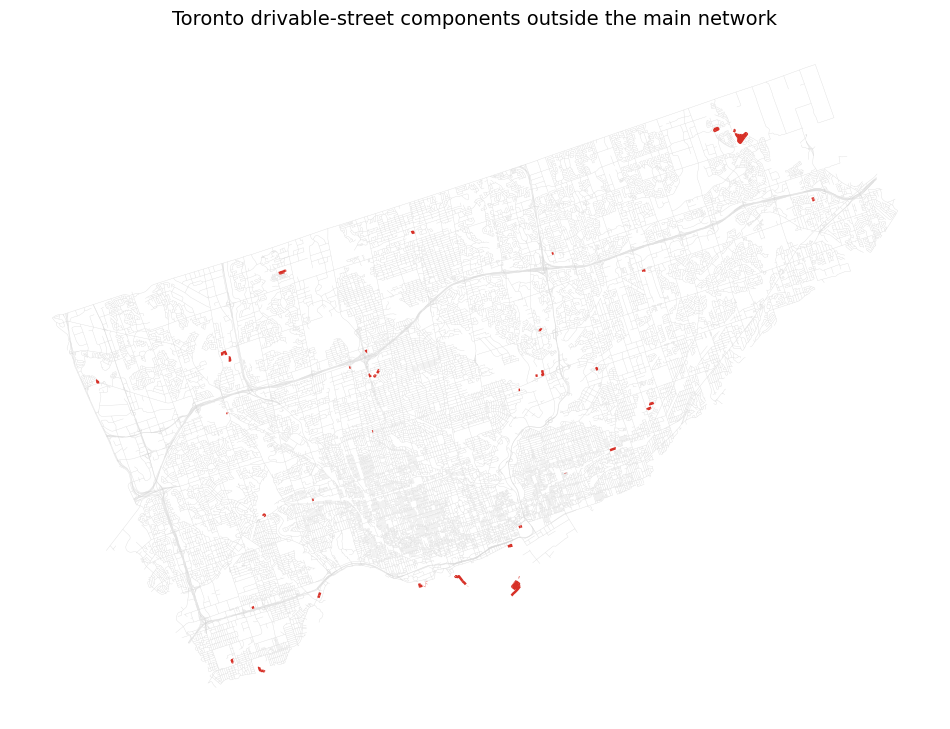

In [7]:
import matplotlib.pyplot as plt

small_component_edges = component_edges[
    component_edges["component_id"] != 1
].copy()

fig, ax = plt.subplots(figsize=(12, 12))

component_edges[
    component_edges["component_id"] == 1
].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.25,
)

small_component_edges.plot(
    ax=ax,
    color="#d73027",
    linewidth=1.8,
)

ax.set_title(
    "Toronto drivable-street components outside the main network",
    fontsize=14,
)
ax.set_axis_off()

plt.show()

In [8]:
largest_small_component_ids = (
    component_summary.drop(index=1)
    .head(8)
    .index
)

component_details = (
    small_component_edges[
        small_component_edges["component_id"].isin(
            largest_small_component_ids
        )
    ]
    .groupby("component_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

display(component_details)

,street_labels,feature_types
component_id,,
2,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway]
3,"[Gristone Cres, Knowles Dr, Loggerhead Grv, Os...",[Local]
4,"[Ln E Haynes S Assiniboine, Ln N Cook E Haynes...",[Laneway]
5,"[Dairy Dr, Ethel Bell Ter, John Bell Cres]",[Local]
6,[Ontario Place Bridge],[Other]
7,[Col Smith Waterfront],[Access Road]
8,[Island Airport],[Access Road]
14,[Bagot Crt],[Laneway]


In [9]:
from src.cleaning import load_centerline, standardize_centerline

raw_centerline = standardize_centerline(
    load_centerline(data_path)
)

excluded_edges = raw_centerline[
    ~raw_centerline["feature_desc"].isin(
        DRIVABLE_STREET_FEATURES
    )
].copy()

excluded_edges["from_component"] = excluded_edges[
    "from_intersection_id"
].map(node_to_component)

excluded_edges["to_component"] = excluded_edges[
    "to_intersection_id"
].map(node_to_component)

touching_excluded_edges = excluded_edges[
    excluded_edges["from_component"].notna()
    | excluded_edges["to_component"].notna()
].copy()

components_to_investigate = [2, 3, 4, 5, 6, 7, 8, 14]

component_connections = touching_excluded_edges[
    touching_excluded_edges["from_component"].isin(
        components_to_investigate
    )
    | touching_excluded_edges["to_component"].isin(
        components_to_investigate
    )
][
    [
        "centerline_id",
        "street_label",
        "feature_desc",
        "from_intersection_id",
        "to_intersection_id",
        "from_component",
        "to_component",
    ]
].sort_values(
    ["from_component", "to_component", "feature_desc"],
    na_position="last",
)

display(component_connections)

,centerline_id,street_label,feature_desc,from_intersection_id,to_intersection_id,from_component,to_component
19037,30024801,Boake St,Pending,20145306,30024800,1.0,4.0
19038,30024804,Haynes Ave,Pending,20015457,30024803,1.0,4.0
19042,30024807,Hackett Ave,Pending,20145297,30024806,1.0,4.0
18291,30012958,Bell Estate Rd,Pending,20237164,30012908,1.0,5.0
24304,1147603,Toronto Islands,Major Shoreline,13469332,13469071,2.0,NaN
24305,3814303,Algonquin Island,Major Shoreline,13469323,13469493,2.0,NaN
27342,30090046,Cibola Ave,Trail,13469567,30090045,2.0,NaN
29339,30096852,Algonquin Island Park Trl,Trail,30096844,30096851,2.0,NaN
28931,30095235,Staines Rd,Pending,14252616,30095234,3.0,NaN
31493,30105581,Staines Rd,Pending,14252582,30105580,3.0,NaN


In [10]:
pending_scenario_features = (
    set(DRIVABLE_STREET_FEATURES)
    | {"Pending"}
)

pending_edges, pending_cleaning_report = prepare_street_edges(
    raw_centerline,
    included_features=pending_scenario_features,
)

pending_graph = build_street_graph(pending_edges)
pending_network_report = summarize_network(pending_graph)

pending_components = sorted(
    nx.weakly_connected_components(pending_graph),
    key=len,
    reverse=True,
)
pending_main_component = pending_components[0]

pending_effect = []

for component_id in components_to_investigate:
    original_nodes = components[component_id - 1]
    nodes_joining_main = len(
        original_nodes.intersection(pending_main_component)
    )

    pending_effect.append(
        {
            "component_id": component_id,
            "original_nodes": len(original_nodes),
            "nodes_joining_main": nodes_joining_main,
            "fully_joins_main": (
                nodes_joining_main == len(original_nodes)
            ),
        }
    )

pending_effect = pd.DataFrame(pending_effect)

display(
    pd.Series(
        asdict(pending_network_report),
        name="with_pending",
    ).to_frame()
)
display(pending_effect)


,with_pending
nodes,36295.000
directed_edges,94508.000
source_segments,50269.000
weakly_connected_components,13.000
largest_component_nodes,36250.000
largest_component_pct,99.880
self_loop_source_segments,92.000
one_way_source_segments,5985.000
total_source_length_km,6464.024
node_ids_with_endpoint_spread_over_1m,1.000


,component_id,original_nodes,nodes_joining_main,fully_joins_main
0,2,17,0,False
1,3,13,13,True
2,4,10,10,True
3,5,6,6,True
4,6,5,0,False
5,7,5,5,True
6,8,5,0,False
7,14,4,4,True


In [11]:
pending_node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(
        pending_components,
        start=1,
    )
    for node_id in nodes
}

pending_component_edges = pending_edges.copy()

pending_component_edges["component_id"] = (
    pending_component_edges["from_intersection_id"]
    .map(pending_node_to_component)
)

pending_component_summary = (
    pending_component_edges.groupby("component_id")
    .agg(
        node_count=(
            "from_intersection_id",
            lambda values: len(
                set(values)
            ),
        ),
        source_segments=("centerline_id", "size"),
        total_length_km=(
            "length_m",
            lambda values: round(
                values.sum() / 1_000,
                3,
            ),
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

pending_component_summary["node_count"] = [
    len(pending_components[component_id - 1])
    for component_id in pending_component_summary.index
]

display(
    pending_component_summary
    .drop(index=1)
    .sort_values("node_count", ascending=False)
)

,node_count,source_segments,total_length_km,street_labels,feature_types
component_id,,,,,
2,17,20,2.457,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway]
3,5,4,0.353,[Ontario Place Bridge],[Other]
4,5,5,0.797,[Island Airport],[Access Road]
5,2,1,0.024,[Ln 1 E Unity Rd N Torbrick],[Laneway]
6,2,1,0.075,[Ln S Ryding E Runnymede],[Laneway]
7,2,1,0.031,[Withrow St],[Local]
8,2,1,0.017,[Ontario Place Bridge],[Other]
9,2,1,0.008,[Lakeshore Ave],[Local]
10,2,1,0.044,[Ln N Eglinton W Times],[Laneway]


In [12]:
import geopandas as gpd

pending_main_edges = pending_component_edges[
    pending_component_edges["component_id"] == 1
][
    ["centerline_id", "street_label", "geometry"]
].copy()

isolated_component_geometries = (
    pending_component_edges[
        pending_component_edges["component_id"] != 1
    ]
    .dissolve(by="component_id")
    .reset_index()
    [["component_id", "geometry"]]
)

nearest_main_edges = gpd.sjoin_nearest(
    isolated_component_geometries,
    pending_main_edges,
    how="left",
    distance_col="nearest_main_distance_m",
)

nearest_main_edges = (
    nearest_main_edges.sort_values(
        ["component_id", "nearest_main_distance_m"]
    )
    .drop_duplicates("component_id")
    .rename(
        columns={
            "centerline_id": "nearest_centerline_id",
            "street_label": "nearest_street",
        }
    )
    [
        [
            "component_id",
            "nearest_main_distance_m",
            "nearest_centerline_id",
            "nearest_street",
        ]
    ]
)

nearest_main_edges["nearest_main_distance_m"] = (
    nearest_main_edges["nearest_main_distance_m"].round(2)
)

display(
    pending_component_summary
    .drop(index=1)
    .join(nearest_main_edges.set_index("component_id"))
    [
        [
            "node_count",
            "source_segments",
            "total_length_km",
            "street_labels",
            "feature_types",
            "nearest_main_distance_m",
            "nearest_street",
        ]
    ]
)

,node_count,source_segments,total_length_km,street_labels,feature_types,nearest_main_distance_m,nearest_street
component_id,,,,,,,
2,17,20,2.457,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway],1177.07,Unwin Ave
3,5,4,0.353,[Ontario Place Bridge],[Other],108.48,Remembrance Dr
4,5,5,0.797,[Island Airport],[Access Road],183.57,Eireann Quay
5,2,1,0.024,[Ln 1 E Unity Rd N Torbrick],[Laneway],3.01,Ln N Torbrick E Unity Rd
6,2,1,0.075,[Ln S Ryding E Runnymede],[Laneway],13.40,Runnymede Rd
7,2,1,0.031,[Withrow St],[Local],963.75,Unwin Ave
8,2,1,0.017,[Ontario Place Bridge],[Other],55.06,Remembrance Dr
9,2,1,0.008,[Lakeshore Ave],[Local],963.82,Eireann Quay
10,2,1,0.044,[Ln N Eglinton W Times],[Laneway],24.83,Times Rd


In [13]:
main_component_nodes = max(
    nx.weakly_connected_components(street_graph),
    key=len,
)

main_directed_graph = street_graph.subgraph(
    main_component_nodes
).copy()

analysis_graph = nx.Graph()
analysis_graph.add_nodes_from(
    main_directed_graph.nodes(data=True)
)

for start, end, attributes in main_directed_graph.edges(
    data=True
):
    if start == end:
        continue

    source_id = attributes["source_centerline_id"]
    length_m = float(attributes["length_m"])

    if analysis_graph.has_edge(start, end):
        existing = analysis_graph[start][end]
        existing["source_centerline_ids"].add(source_id)
        existing["length_m"] = min(
            existing["length_m"],
            length_m,
        )
    else:
        analysis_graph.add_edge(
            start,
            end,
            length_m=length_m,
            source_centerline_ids={source_id},
        )

assert nx.is_connected(analysis_graph)
assert nx.number_of_selfloops(analysis_graph) == 0

analysis_graph_summary = {
    "nodes": analysis_graph.number_of_nodes(),
    "edges": analysis_graph.number_of_edges(),
    "connected": nx.is_connected(analysis_graph),
    "self_loops": nx.number_of_selfloops(
        analysis_graph
    ),
}

display(
    pd.Series(
        analysis_graph_summary,
        name="value",
    ).to_frame()
)


,value
nodes,35788
edges,48817
connected,True
self_loops,0


In [14]:
main_source_edges = component_edges[
    component_edges["component_id"] == 1
].copy()

main_self_loop_ids = set(
    main_source_edges.loc[
        main_source_edges["from_intersection_id"]
        == main_source_edges["to_intersection_id"],
        "centerline_id",
    ]
)

represented_source_ids = set().union(
    *[
        attributes["source_centerline_ids"]
        for _, _, attributes in analysis_graph.edges(
            data=True
        )
    ]
)

expected_source_ids = (
    set(main_source_edges["centerline_id"])
    - main_self_loop_ids
)

assert represented_source_ids == expected_source_ids

parallel_edge_groups = sum(
    len(attributes["source_centerline_ids"]) > 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

extra_parallel_segments = sum(
    len(attributes["source_centerline_ids"]) - 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

collapse_summary = {
    "main_source_segments": len(main_source_edges),
    "removed_self_loop_segments": len(
        main_self_loop_ids
    ),
    "represented_source_segments": len(
        represented_source_ids
    ),
    "simple_graph_edges": (
        analysis_graph.number_of_edges()
    ),
    "parallel_edge_groups": parallel_edge_groups,
    "extra_parallel_segments": (
        extra_parallel_segments
    ),
}

display(
    pd.Series(
        collapse_summary,
        name="value",
    ).to_frame()
)

,value
main_source_segments,49442
removed_self_loop_segments,92
represented_source_segments,49350
simple_graph_edges,48817
parallel_edge_groups,532
extra_parallel_segments,533


In [15]:
degree_by_node = pd.Series(
    dict(analysis_graph.degree()),
    name="degree",
)

assert (
    degree_by_node.sum()
    == 2 * analysis_graph.number_of_edges()
)

degree_distribution = (
    degree_by_node.value_counts()
    .sort_index()
    .rename_axis("degree")
    .reset_index(name="node_count")
)

degree_distribution["node_pct"] = (
    degree_distribution["node_count"]
    / analysis_graph.number_of_nodes()
    * 100
).round(2)

degree_summary = {
    "nodes": analysis_graph.number_of_nodes(),
    "minimum_degree": int(degree_by_node.min()),
    "median_degree": float(degree_by_node.median()),
    "mean_degree": round(
        float(degree_by_node.mean()),
        3,
    ),
    "maximum_degree": int(degree_by_node.max()),
    "terminal_nodes_degree_1": int(
        (degree_by_node == 1).sum()
    ),
    "through_nodes_degree_2": int(
        (degree_by_node == 2).sum()
    ),
    "junction_nodes_degree_3_plus": int(
        (degree_by_node >= 3).sum()
    ),
}

display(
    pd.Series(
        degree_summary,
        name="value",
    ).to_frame()
)

display(degree_distribution)

,value
nodes,35788.000
minimum_degree,1.000
median_degree,3.000
mean_degree,2.728
maximum_degree,6.000
terminal_nodes_degree_1,4824.000
through_nodes_degree_2,6382.000
junction_nodes_degree_3_plus,24582.000


,degree,node_count,node_pct
0,1,4824,13.48
1,2,6382,17.83
2,3,18415,51.46
3,4,6047,16.90
4,5,107,0.30
5,6,13,0.04


In [16]:
high_degree_ids = set(
    degree_by_node[
        degree_by_node >= 5
    ].index
)

edge_endpoints = pd.concat(
    [
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "from_intersection_id",
            ]
        ].rename(
            columns={
                "from_intersection_id":
                    "intersection_id"
            }
        ),
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "to_intersection_id",
            ]
        ].rename(
            columns={
                "to_intersection_id":
                    "intersection_id"
            }
        ),
    ],
    ignore_index=True,
)

high_degree_details = (
    edge_endpoints[
        edge_endpoints["intersection_id"].isin(
            high_degree_ids
        )
    ]
    .groupby("intersection_id")
    .agg(
        source_segments=(
            "centerline_id",
            "nunique",
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .sort_values(
        ["degree", "source_segments"],
        ascending=False,
    )
)

display(high_degree_details)

,source_segments,street_labels,feature_types,degree
intersection_id,,,,
13460573,8,"[27 N Dixon W Ramp, Dixon E 27 N Ramp, Dixon R...","[Major Arterial, Major Arterial Ramp]",6
13454202,7,"[Eglinton Ave E, Eglinton E Wynford Dr Ramp, W...","[Major Arterial, Major Arterial Ramp, Minor Ar...",6
13453585,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13453685,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13455995,6,"[401 C E 400 N Ramp, 401 C W 400 S Ramp, 401 E...","[Expressway, Expressway Ramp]",6
...,...,...,...,...
13470060,5,"[Gardiner X W 427 X N Ramp, Gardiner X W Brown...","[Expressway Ramp, Minor Arterial]",5
13470102,5,"[Browns Li N 427 C N Ramp, Evans W 427 C N Ram...","[Expressway, Expressway Ramp]",5
13470208,5,"[427 C S Qew X W Ramp, Evans Ave, QEW]","[Expressway, Expressway Ramp, Major Arterial]",5


In [17]:
from time import perf_counter

BETWEENNESS_SAMPLE_SIZE = 500
BETWEENNESS_SEED = 42

started_at = perf_counter()

betweenness = nx.betweenness_centrality(
    analysis_graph,
    k=BETWEENNESS_SAMPLE_SIZE,
    normalized=True,
    weight="length_m",
    endpoints=False,
    seed=BETWEENNESS_SEED,
)

elapsed_seconds = perf_counter() - started_at

betweenness_by_node = pd.Series(
    betweenness,
    name="betweenness",
)

assert len(betweenness_by_node) == (
    analysis_graph.number_of_nodes()
)
assert betweenness_by_node.notna().all()
assert betweenness_by_node.between(0, 1).all()

node_street_context = (
    edge_endpoints.groupby("intersection_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

top_betweenness = (
    betweenness_by_node
    .nlargest(20)
    .rename_axis("intersection_id")
    .to_frame()
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .join(node_street_context)
)

top_betweenness["betweenness"] = (
    top_betweenness["betweenness"].round(6)
)

run_summary = {
    "sample_size": BETWEENNESS_SAMPLE_SIZE,
    "seed": BETWEENNESS_SEED,
    "elapsed_seconds": round(elapsed_seconds, 2),
    "nodes_scored": len(betweenness_by_node),
    "nonzero_nodes": int(
        (betweenness_by_node > 0).sum()
    ),
}

display(
    pd.Series(run_summary, name="value").to_frame()
)
display(top_betweenness)

,value
sample_size,500.00
seed,42.00
elapsed_seconds,58.84
nodes_scored,35788.00
nonzero_nodes,30275.00


,betweenness,degree,street_labels,feature_types
intersection_id,,,,
13463022,0.127542,4,"[Bloor St E, Rosedale Valley Rd]","[Major Arterial, Minor Arterial]"
13462475,0.109994,4,"[DVP, Prince Edward Viaduct]","[Expressway, Major Arterial]"
13462592,0.104916,4,"[Bayview Ave, Prince Edward Viaduct]",[Major Arterial]
30003677,0.104417,2,[Prince Edward Viaduct],[Major Arterial]
13462572,0.104408,2,[Prince Edward Viaduct],[Major Arterial]
13462540,0.104402,2,[Prince Edward Viaduct],[Major Arterial]
30003616,0.104397,2,[Prince Edward Viaduct],[Major Arterial]
13462482,0.104394,2,[Prince Edward Viaduct],[Major Arterial]
13462709,0.104135,3,"[Bloor St E, Drumsnab Rd]","[Local, Major Arterial]"


In [18]:
import time

SECOND_SEED = 2026
SAMPLE_SIZE = 500

started = time.perf_counter()

betweenness_seed_2026 = nx.betweenness_centrality(
    analysis_graph,
    k=SAMPLE_SIZE,
    normalized=True,
    weight="length_m",
    endpoints=False,
    seed=SECOND_SEED,
)

elapsed_seconds = time.perf_counter() - started

betweenness_second = pd.Series(
    betweenness_seed_2026,
    name="betweenness_seed_2026",
)

comparison = pd.concat(
    [
        betweenness_by_node.rename("betweenness_seed_42"),
        betweenness_second,
    ],
    axis=1,
)

comparison["rank_seed_42"] = comparison[
    "betweenness_seed_42"
].rank(method="average", ascending=False)

comparison["rank_seed_2026"] = comparison[
    "betweenness_seed_2026"
].rank(method="average", ascending=False)

# Pearson correlation between ranks is Spearman rank correlation.
spearman_all_nodes = comparison[
    ["rank_seed_42", "rank_seed_2026"]
].corr().iloc[0, 1]

stability_rows = []

for top_n in (20, 100, 500):
    first_ids = set(
        comparison["betweenness_seed_42"].nlargest(top_n).index
    )
    second_ids = set(
        comparison["betweenness_seed_2026"].nlargest(top_n).index
    )

    overlap = len(first_ids & second_ids)
    union = len(first_ids | second_ids)

    stability_rows.append(
        {
            "top_n": top_n,
            "overlap": overlap,
            "overlap_pct": round(100 * overlap / top_n, 2),
            "jaccard": round(overlap / union, 3),
        }
    )

stability_summary = pd.DataFrame(stability_rows)

display(
    pd.Series(
        {
            "second_seed": SECOND_SEED,
            "sample_size": SAMPLE_SIZE,
            "elapsed_seconds": round(elapsed_seconds, 2),
            "spearman_all_nodes": round(spearman_all_nodes, 3),
        },
        name="value",
    ).to_frame()
)

display(stability_summary)

,value
second_seed,2026.000
sample_size,500.000
elapsed_seconds,51.550
spearman_all_nodes,0.965


,top_n,overlap,overlap_pct,jaccard
0,20,19,95.0,0.905
1,100,87,87.0,0.770
2,500,425,85.0,0.739


In [19]:
top_20_seed_42 = set(comparison["betweenness_seed_42"].nlargest(20).index)
top_20_seed_2026 = set(comparison["betweenness_seed_2026"].nlargest(20).index)
top_20_union = top_20_seed_42 | top_20_seed_2026
top_20_comparison = (
    comparison.loc[list(top_20_union)]
    .join(node_street_context, how="left")
    .assign(
        mean_rank=lambda frame: frame[
            ["rank_seed_42", "rank_seed_2026"]
        ].mean(axis=1),
        absolute_rank_change=lambda frame: (
            frame["rank_seed_42"] - frame["rank_seed_2026"]
        ).abs(),
        appears_in_both=lambda frame: frame.index.map(
            lambda node_id:
                node_id in top_20_seed_42
                and node_id in top_20_seed_2026
        ),
    )
    .sort_values(["appears_in_both", "mean_rank"], ascending=[False, True])
)

display(top_20_comparison)


,betweenness_seed_42,betweenness_seed_2026,rank_seed_42,rank_seed_2026,street_labels,feature_types,mean_rank,absolute_rank_change,appears_in_both
13463022,0.127542,0.128242,1.0,1.0,"[Bloor St E, Rosedale Valley Rd]","[Major Arterial, Minor Arterial]",1.0,0.0,True
13462475,0.109994,0.111552,2.0,2.0,"[DVP, Prince Edward Viaduct]","[Expressway, Major Arterial]",2.0,0.0,True
13462592,0.104916,0.104289,3.0,5.0,"[Bayview Ave, Prince Edward Viaduct]",[Major Arterial],4.0,2.0,True
30003677,0.104417,0.104028,4.0,6.0,[Prince Edward Viaduct],[Major Arterial],5.0,2.0,True
13462572,0.104408,0.104021,5.0,7.0,[Prince Edward Viaduct],[Major Arterial],6.0,2.0,True
13462540,0.104402,0.104016,6.0,8.0,[Prince Edward Viaduct],[Major Arterial],7.0,2.0,True
13462813,0.103163,0.104720,11.0,4.0,"[Bloor St E, Castle Frank Rd]","[Local, Major Arterial]",7.5,7.0,True
13462893,0.102612,0.104727,12.0,3.0,"[Bloor St E, Castle Frank Cres]","[Local, Major Arterial]",7.5,9.0,True
30003616,0.104397,0.104013,7.0,9.0,[Prince Edward Viaduct],[Major Arterial],8.0,2.0,True
13462482,0.104394,0.104010,8.0,10.0,[Prince Edward Viaduct],[Major Arterial],9.0,2.0,True


In [20]:
def street_ranking(
    scores,
    node_context,
    top_node_count=500,
):
    top_scores = scores.nlargest(top_node_count).rename("betweenness")

    ranked_nodes = (
        top_scores.to_frame()
        .join(node_context[["street_labels"]], how="left")
        .reset_index(names="intersection_id")   # ← fix: pin column name
    )

    ranked_streets = (
        ranked_nodes
        .explode("street_labels")
        .dropna(subset=["street_labels"])
        .groupby("street_labels")
        .agg(
            maximum_betweenness=("betweenness", "max"),
            mean_betweenness=("betweenness", "mean"),
            contributing_nodes=("intersection_id", "nunique"),
        )
        .sort_values("maximum_betweenness", ascending=False)
    )

    return ranked_streets


streets_seed_42 = street_ranking(
    betweenness_by_node,
    node_street_context,
)

streets_seed_2026 = street_ranking(
    betweenness_second,
    node_street_context,
)

top_n = 20

seed_42_streets = set(streets_seed_42.head(top_n).index)
seed_2026_streets = set(streets_seed_2026.head(top_n).index)

shared_streets = seed_42_streets & seed_2026_streets

street_stability = pd.Series(
    {
        "top_n": top_n,
        "shared_streets": len(shared_streets),
        "overlap_pct": round(
            100 * len(shared_streets) / top_n,
            2,
        ),
        "jaccard": round(
            len(shared_streets)
            / len(seed_42_streets | seed_2026_streets),
            3,
        ),
    },
    name="value",
).to_frame()

street_comparison = (
    streets_seed_42[["maximum_betweenness"]]
    .rename(columns={
        "maximum_betweenness": "maximum_seed_42"
    })
    .join(
        streets_seed_2026[["maximum_betweenness"]]
        .rename(columns={
            "maximum_betweenness": "maximum_seed_2026"
        }),
        how="outer",
    )
)

street_comparison["rank_seed_42"] = (
    street_comparison["maximum_seed_42"]
    .rank(ascending=False)
)

street_comparison["rank_seed_2026"] = (
    street_comparison["maximum_seed_2026"]
    .rank(ascending=False)
)

street_comparison["mean_rank"] = street_comparison[
    ["rank_seed_42", "rank_seed_2026"]
].mean(axis=1)

display(street_stability)


,value
top_n,20.000
shared_streets,19.000
overlap_pct,95.000
jaccard,0.905


In [21]:
from shapely.geometry import Point

top20_points = gpd.GeoDataFrame(
    top_betweenness.copy(),
    geometry=[
        Point(
            analysis_graph.nodes[node_id]["x"],
            analysis_graph.nodes[node_id]["y"],
        )
        for node_id in top_betweenness.index
    ],
    crs=street_edges.crs,
)

assert len(top20_points) == 20
assert top20_points.geometry.notna().all()
assert not top20_points.geometry.is_empty.any()

display(
    top20_points[
        ["betweenness", "street_labels", "geometry"]
    ].head()
)
print("CRS:", top20_points.crs)

,betweenness,street_labels,geometry
intersection_id,,,
13463022,0.127542,"[Bloor St E, Rosedale Valley Rd]",POINT (631407.896 4836798.594)
13462475,0.109994,"[DVP, Prince Edward Viaduct]",POINT (632069.393 4837155.099)
13462592,0.104916,"[Bayview Ave, Prince Edward Viaduct]",POINT (631819.79 4837083.571)
30003677,0.104417,[Prince Edward Viaduct],POINT (631842.589 4837090.11)
13462572,0.104408,[Prince Edward Viaduct],POINT (631858.871 4837094.78)


CRS: EPSG:26917


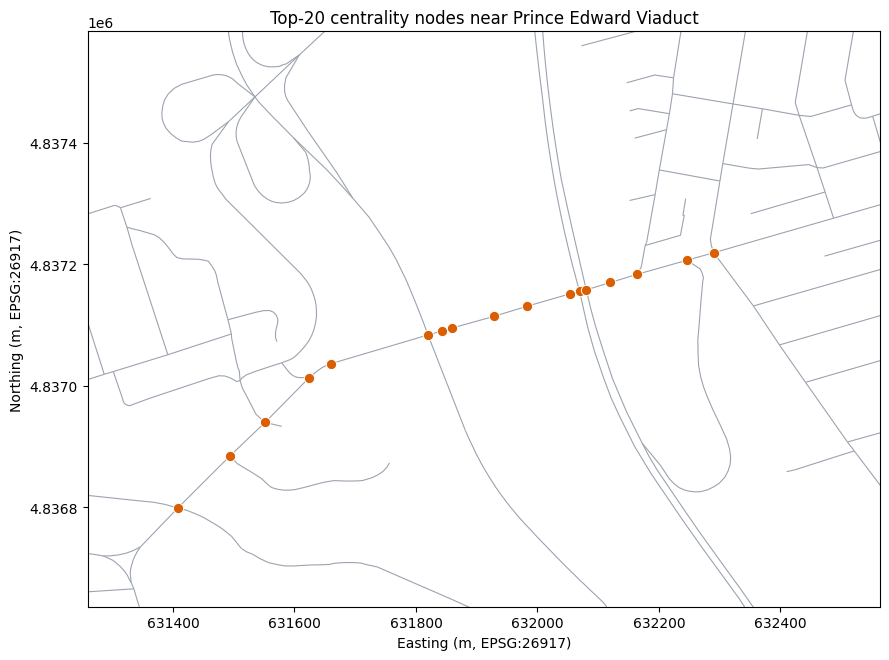

Top-20 nodes in view: 17


In [22]:
import matplotlib.pyplot as plt

bridge_points = top20_points[
    top20_points["street_labels"].apply(
        lambda names: "Prince Edward Viaduct" in names
    )
]
assert not bridge_points.empty
assert top20_points.crs == street_edges.crs

left, bottom, right, top = bridge_points.total_bounds
padding_m = 400
xmin, xmax = left - padding_m, right + padding_m
ymin, ymax = bottom - padding_m, top + padding_m

streets_in_view = street_edges.cx[xmin:xmax, ymin:ymax]
points_in_view = top20_points.cx[xmin:xmax, ymin:ymax]

fig, ax = plt.subplots(figsize=(9, 8))
streets_in_view.plot(ax=ax, color="#9ca3af", linewidth=0.8)
points_in_view.plot(
    ax=ax,
    color="#d95f02",
    markersize=55,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_title("Top-20 centrality nodes near Prince Edward Viaduct")
ax.set_xlabel("Easting (m, EPSG:26917)")
ax.set_ylabel("Northing (m, EPSG:26917)")
plt.tight_layout()
plt.show()

print("Top-20 nodes in view:", len(points_in_view))

In [23]:
corridor_check = points_in_view[
    ["betweenness", "street_labels"]
].copy()

corridor_check["degree"] = [
    analysis_graph.degree[node_id]
    for node_id in corridor_check.index
]
corridor_check["easting_m"] = (
    points_in_view.geometry.x.round(1)
)

display(corridor_check.sort_values("easting_m"))
print("Nodes in view:", len(corridor_check))
print("Degree-2 nodes:", (corridor_check["degree"] == 2).sum())

,betweenness,street_labels,degree,easting_m
intersection_id,,,,
13463022,0.127542,"[Bloor St E, Rosedale Valley Rd]",4,631407.9
13462893,0.102612,"[Bloor St E, Castle Frank Cres]",3,631493.6
13462813,0.103163,"[Bloor St E, Castle Frank Rd]",4,631551.6
13462709,0.104135,"[Bloor St E, Drumsnab Rd]",3,631624.3
13462661,0.104127,"[Bloor St E, Prince Edward Viaduct]",2,631659.7
13462592,0.104916,"[Bayview Ave, Prince Edward Viaduct]",4,631819.8
30003677,0.104417,[Prince Edward Viaduct],2,631842.6
13462572,0.104408,[Prince Edward Viaduct],2,631858.9
13462540,0.104402,[Prince Edward Viaduct],2,631928.0


Nodes in view: 17
Degree-2 nodes: 7


In [24]:
junction_ids = (13462592, 13462475, 13462471)
rows = []

for node_id in junction_ids:
    incident = main_source_edges.loc[
        main_source_edges["from_intersection_id"].eq(node_id)
        | main_source_edges["to_intersection_id"].eq(node_id),
        [
            "centerline_id",
            "street_label",
            "feature_desc",
            "oneway_desc",
            "length_m",
            "from_intersection_id",
            "to_intersection_id",
        ],
    ].copy()
    incident.insert(0, "checked_node", node_id)
    rows.append(incident)

junction_audit = (
    pd.concat(rows, ignore_index=True)
    .sort_values(["checked_node", "street_label", "centerline_id"])
)

display(junction_audit.round({"length_m": 1}))

,checked_node,centerline_id,street_label,feature_desc,oneway_desc,length_m,from_intersection_id,to_intersection_id
10,13462471,1141437,DVP,Expressway,Follow-Digitization,269.5,13462862,13462471
11,13462471,60024132,DVP,Expressway,Follow-Digitization,796.3,13462471,13461194
8,13462471,1141001,Prince Edward Viaduct,Major Arterial,Not One-Way,11.3,13462475,13462471
9,13462471,30096652,Prince Edward Viaduct,Major Arterial,Not One-Way,41.5,13462471,30096651
6,13462475,60024037,DVP,Expressway,Against-Digitization,971.1,30003563,13462475
7,13462475,60024103,DVP,Expressway,Against-Digitization,602.3,13462475,13461517
4,13462475,1141001,Prince Edward Viaduct,Major Arterial,Not One-Way,11.3,13462475,13462471
5,13462475,1141008,Prince Edward Viaduct,Major Arterial,Not One-Way,16.1,13462482,13462475
0,13462592,1141139,Bayview Ave,Major Arterial,Not One-Way,258.4,13462592,13462245
2,13462592,30057486,Bayview Ave,Major Arterial,Not One-Way,169.1,30057484,13462592


In [25]:
turn_checks = [
    ("DVP to viaduct", 13461517, 13462475, 13462482),
    ("Bayview to viaduct", 30057484, 13462592, 30003677),
]

for label, incoming, junction, outgoing in turn_checks:
    print(
        label,
        "incoming:", street_graph.has_edge(incoming, junction),
        "outgoing:", street_graph.has_edge(junction, outgoing),
    )

DVP to viaduct incoming: True outgoing: True
Bayview to viaduct incoming: True outgoing: True


In [27]:
%pip install truststore


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import json
import ssl
import truststore
import pandas as pd
from datetime import datetime, timezone
from urllib.parse import urlencode
from urllib.request import urlopen

intersection_url = (
    "https://gis.toronto.ca/arcgis/rest/services/"
    "cot_geospatial/MapServer/19/query"
)
ssl_context = truststore.SSLContext(ssl.PROTOCOL_TLS_CLIENT)

records = []
offset = 0

while True:
    params = {
        "where": "NUMBER_OF_ELEVATIONS > 1",
        "outFields": (
            "INTERSECTION_ID,INTERSECTION_DESC,"
            "CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS"
        ),
        "returnGeometry": "false",
        "orderByFields": "OBJECTID ASC",
        "resultOffset": offset,
        "resultRecordCount": 2000,
        "f": "json",
    }

    with urlopen(
        f"{intersection_url}?{urlencode(params)}",
        timeout=60,
        context=ssl_context,
    ) as response:
        payload = json.load(response)

    if "error" in payload:
        raise RuntimeError(payload["error"])

    features = payload["features"]
    records.extend(feature["attributes"] for feature in features)

    if not payload.get("exceededTransferLimit", False):
        break
    if not features:
        raise RuntimeError("Pagination stopped making progress.")

    offset += len(features)

# Preserve every downloaded record.
intersection_audit_raw = pd.DataFrame(records)
assert not intersection_audit_raw.empty

audit_fields = [
    "INTERSECTION_ID",
    "INTERSECTION_DESC",
    "CLASSIFICATION_DESC",
    "NUMBER_OF_ELEVATIONS",
]

# Collapse only rows that agree across all audit fields.
intersection_audit = (
    intersection_audit_raw[audit_fields]
    .drop_duplicates()
    .reset_index(drop=True)
)

conflicts = intersection_audit[
    intersection_audit.duplicated("INTERSECTION_ID", keep=False)
]

if not conflicts.empty:
    display(conflicts)
    raise ValueError("Conflicting intersection records need review.")

print("Downloaded records:", len(intersection_audit_raw))
print("Unique audit rows:", len(intersection_audit))

affected_nodes = intersection_audit[
    intersection_audit["INTERSECTION_ID"].isin(
        list(analysis_graph.nodes)
    )
].copy()

print("Retrieved:", datetime.now(timezone.utc).isoformat())
print("City multi-elevation records:", len(intersection_audit))
print("Present in analysis graph:", len(affected_nodes))
display(affected_nodes.head(15))

Downloaded records: 2081
Unique audit rows: 2080
Retrieved: 2026-09-19T12:35:03.110750+00:00
City multi-elevation records: 2080
Present in analysis graph: 1743


,INTERSECTION_ID,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS
0,13469842,The Queensway / Plywood Pl,Pseudo Intersection-Overpass/Underpass,2
1,13469952,Kipling Ave / Kipling S Gardiner C E Ramp,Minor-Multi Level,2
2,13469930,Gardiner XWY / Kipling Ave / Kipling N Gardine...,Minor-Multi Level,2
3,13469826,Gardiner XWY / Islington Ave / Islington S Gar...,Minor-Multi Level,2
4,13470316,Kipling Ave / C N R,Pseudo Intersection-Overpass/Underpass,2
6,13470763,Lakeshore Rd E,Pseudo Intersection-Overpass/Underpass,2
8,13460931,Dixon Rd / Mimico Creek,Pseudo Intersection-Overpass/Underpass,2
9,13460406,Martin Grove Rd / 401 X E Dixon Ramp,Pseudo Intersection-Overpass/Underpass,2
10,13460331,Highway 401 / Martin Grove Rd,Pseudo Intersection-Overpass/Underpass,2
11,13460278,Highway 401 / Martin Grove Rd / Dixon W 401 X ...,Pseudo Intersection-Overpass/Underpass,2


In [31]:
node_audit = affected_nodes.set_index("INTERSECTION_ID").copy()

node_audit["graph_degree"] = pd.Series(
    dict(analysis_graph.degree)
)
node_audit["in_top20"] = node_audit.index.isin(
    top_betweenness.index
)

classification_summary = (
    node_audit.groupby("CLASSIFICATION_DESC")
    .agg(
        nodes=("graph_degree", "size"),
        degree_3_plus=(
            "graph_degree",
            lambda values: int((values >= 3).sum()),
        ),
        top20_nodes=("in_top20", "sum"),
    )
    .sort_values("nodes", ascending=False)
)

flagged_top20 = top_betweenness.join(
    node_audit[
        ["CLASSIFICATION_DESC", "NUMBER_OF_ELEVATIONS"]
    ],
    how="inner",
)

display(classification_summary)
display(
    flagged_top20[
        [
            "betweenness",
            "street_labels",
            "degree",
            "CLASSIFICATION_DESC",
            "NUMBER_OF_ELEVATIONS",
        ]
    ]
)

print("Top-20 nodes flagged:", len(flagged_top20))

,nodes,degree_3_plus,top20_nodes
CLASSIFICATION_DESC,,,
Pseudo Intersection-Overpass/Underpass,1538,820,10
Minor-Multi Level,86,86,0
Lesser-Multi Level,59,5,0
Pseudo Intersection-Single Level,23,0,0
Minor-Single Level,14,12,0
Lesser-Single Level,13,1,0
Major-Multi Level,10,10,0


,betweenness,street_labels,degree,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS
13463022,0.127542,"[Bloor St E, Rosedale Valley Rd]",4,Pseudo Intersection-Overpass/Underpass,2
13462475,0.109994,"[DVP, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
13462592,0.104916,"[Bayview Ave, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
30003677,0.104417,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462572,0.104408,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462540,0.104402,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
30003616,0.104397,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462482,0.104394,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462471,0.088283,"[DVP, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
13452658,0.081928,"[Bathurst St, Highway 401]",4,Pseudo Intersection-Overpass/Underpass,2


Top-20 nodes flagged: 10


In [32]:
crossing_groups = {
    13462475: {
        "viaduct": {1141001, 1141008},
        "dvp": {60024037, 60024103},
    },
    13462471: {
        "viaduct": {1141001, 30096652},
        "dvp": {1141437, 60024132},
    },
    13462592: {
        "viaduct": {1141214, 30003678},
        "bayview": {1141139, 30057486},
    },
}

checks = []

for node_id, groups in crossing_groups.items():
    incident_ids = set(
        street_edges.loc[
            street_edges["from_intersection_id"].eq(node_id)
            | street_edges["to_intersection_id"].eq(node_id),
            "centerline_id",
        ]
    )

    assigned_ids = [
        segment_id
        for group_ids in groups.values()
        for segment_id in group_ids
    ]

    assert len(assigned_ids) == len(set(assigned_ids)), (
        f"{node_id}: a segment was assigned to multiple groups"
    )
    assert set(assigned_ids) == incident_ids, (
        f"{node_id}: assignments do not match the source segments"
    )

    checks.append({
        "intersection_id": node_id,
        "source_segments": len(incident_ids),
        "separate_road_groups": len(groups),
    })

display(pd.DataFrame(checks))

,intersection_id,source_segments,separate_road_groups
0,13462475,4,2
1,13462471,4,2
2,13462592,4,2


In [33]:
def split_reviewed_crossings(
    graph: nx.MultiDiGraph,
    groups: dict,
) -> nx.MultiDiGraph:
    endpoint_map = {}

    for node_id, road_groups in groups.items():
        assigned = [
            segment_id
            for segment_ids in road_groups.values()
            for segment_id in segment_ids
        ]
        incident = {
            data["source_centerline_id"]
            for edges in (
                graph.in_edges(node_id, data=True),
                graph.out_edges(node_id, data=True),
            )
            for _, _, data in edges
        }

        if (
            len(assigned) != len(set(assigned))
            or set(assigned) != incident
        ):
            raise ValueError(f"Invalid assignments for {node_id}")

        for road_group, segment_ids in road_groups.items():
            for segment_id in segment_ids:
                endpoint_map[node_id, segment_id] = (
                    node_id, road_group
                )

    result = graph.copy()

    for node_id, road_groups in groups.items():
        attributes = dict(graph.nodes[node_id])

        # These measurements describe the original source node.
        for name in ("endpoint_observations", "endpoint_spread_m"):
            if name in attributes:
                attributes["source_" + name] = attributes.pop(name)

        result.remove_node(node_id)

        for road_group in road_groups:
            result.add_node(
                (node_id, road_group),
                **attributes,
                source_intersection_id=node_id,
                road_group=road_group,
            )

    # Reconnect affected edges using their reviewed road groups.
    for start, end, key, attributes in graph.edges(
        keys=True, data=True
    ):
        if start in groups or end in groups:
            source_id = attributes["source_centerline_id"]

            result.add_edge(
                endpoint_map.get((start, source_id), start),
                endpoint_map.get((end, source_id), end),
                key=key,
                **attributes,
            )

    return result


corrected_graph = split_reviewed_crossings(
    street_graph, crossing_groups
)

In [34]:
through_routes = {
    "DVP carriageway 1": [
        13461517, (13462475, "dvp"), 30003563
    ],
    "DVP carriageway 2": [
        13462862, (13462471, "dvp"), 13461194
    ],
    "Bayview": [
        30057484, (13462592, "bayview"), 13462245
    ],
    "Viaduct across DVP": [
        13462482,
        (13462475, "viaduct"),
        (13462471, "viaduct"),
        30096651,
    ],
    "Viaduct across Bayview": [
        13462661, (13462592, "viaduct"), 30003677
    ],
}

for name, route in through_routes.items():
    assert nx.is_path(corrected_graph, route), name
    print(f"{name}: connected")

for node_id, road_groups in crossing_groups.items():
    for first in road_groups:
        for second in road_groups:
            if first != second:
                assert not corrected_graph.has_edge(
                    (node_id, first), (node_id, second)
                )

assert corrected_graph.number_of_edges() == street_graph.number_of_edges()
assert corrected_graph.number_of_nodes() == street_graph.number_of_nodes() + 3

print("Direct switches between levels: blocked")
print("Nodes:", corrected_graph.number_of_nodes())
print("Directed edges:", corrected_graph.number_of_edges())

DVP carriageway 1: connected
DVP carriageway 2: connected
Bayview: connected
Viaduct across DVP: connected
Viaduct across Bayview: connected
Direct switches between levels: blocked
Nodes: 35956
Directed edges: 93144


In [35]:
def make_analysis_graph(
    directed_graph: nx.MultiDiGraph,
) -> nx.Graph:
    main_nodes = max(
        nx.weakly_connected_components(directed_graph),
        key=len,
    )
    main_graph = directed_graph.subgraph(main_nodes)

    result = nx.Graph(**directed_graph.graph)
    result.add_nodes_from(main_graph.nodes(data=True))

    for start, end, attributes in main_graph.edges(data=True):
        if start == end:
            continue

        source_id = attributes["source_centerline_id"]
        length_m = float(attributes["length_m"])

        if result.has_edge(start, end):
            existing = result[start][end]
            existing["source_centerline_ids"].add(source_id)
            existing["length_m"] = min(
                existing["length_m"], length_m
            )
        else:
            result.add_edge(
                start,
                end,
                length_m=length_m,
                source_centerline_ids={source_id},
            )

    return result


corrected_analysis_graph = make_analysis_graph(corrected_graph)


def represented_segments(graph):
    return {
        source_id
        for _, _, attributes in graph.edges(data=True)
        for source_id in attributes["source_centerline_ids"]
    }


# Check that selecting the largest component retained the same segments.
assert represented_segments(corrected_analysis_graph) == (
    represented_segments(analysis_graph)
), "Largest-component segment membership changed; inspect before scoring."

comparison_rows = []

for label, directed, simple in [
    ("baseline", street_graph, analysis_graph),
    ("three_crossings_corrected", corrected_graph, corrected_analysis_graph),
]:
    comparison_rows.append({
        "version": label,
        "weak_components": nx.number_weakly_connected_components(directed),
        "analysis_nodes": simple.number_of_nodes(),
        "analysis_edges": simple.number_of_edges(),
        "represented_segments": len(represented_segments(simple)),
        "self_loops": nx.number_of_selfloops(simple),
    })

display(pd.DataFrame(comparison_rows).set_index("version"))

,weak_components,analysis_nodes,analysis_edges,represented_segments,self_loops
version,,,,,
baseline,49,35788,48817,49350,0
three_crossings_corrected,49,35791,48817,49350,0


In [36]:
for name, graph in [
    ("Original graph", street_graph),
    ("Corrected graph", corrected_graph),
]:
    print(
        f"{name}: "
        f"{graph.number_of_nodes():,} nodes, "
        f"{graph.number_of_edges():,} directed edges"
    )

Original graph: 35,953 nodes, 93,144 directed edges
Corrected graph: 35,956 nodes, 93,144 directed edges


In [37]:
import random
from time import perf_counter

shared_nodes = sorted(
    set(analysis_graph.nodes)
    & set(corrected_analysis_graph.nodes)
)

AUDIT_SAMPLE_SIZE = 500
AUDIT_SEED = 42

sampled_origins = random.Random(AUDIT_SEED).sample(
    shared_nodes,
    AUDIT_SAMPLE_SIZE,
)

paired_scores = pd.DataFrame(
    index=pd.Index(shared_nodes, name="intersection_id")
)

for label, graph in [
    ("baseline", analysis_graph),
    ("corrected", corrected_analysis_graph),
]:
    started = perf_counter()

    scores = nx.betweenness_centrality_subset(
        graph,
        sources=sampled_origins,
        targets=shared_nodes,
        normalized=False,
        weight="length_m",
    )

    paired_scores[label] = [
        scores[node_id] for node_id in shared_nodes
    ]

    print(
        f"{label}: completed in "
        f"{perf_counter() - started:.1f} seconds",
        flush=True,
    )

paired_ranks = paired_scores.rank(
    method="average",
    ascending=False,
)

baseline_top20 = set(
    paired_scores["baseline"].nlargest(20).index
)
corrected_top20 = set(
    paired_scores["corrected"].nlargest(20).index
)

comparison_summary = {
    "sampled_origins": len(sampled_origins),
    "shared_destinations": len(shared_nodes),
    "spearman_shared_nodes": round(
        paired_ranks.corr().loc["baseline", "corrected"], 4
    ),
    "top20_overlap": len(baseline_top20 & corrected_top20),
    "top20_overlap_pct": (
        100 * len(baseline_top20 & corrected_top20) / 20
    ),
}

display(
    pd.Series(comparison_summary, name="value").to_frame()
)

baseline: completed in 46.7 seconds
corrected: completed in 48.5 seconds


,value
sampled_origins,500.0000
shared_destinations,35785.0000
spearman_shared_nodes,0.9997
top20_overlap,20.0000
top20_overlap_pct,100.0000


In [38]:
score_changes = paired_scores.copy()

score_changes["baseline_rank"] = paired_ranks["baseline"]
score_changes["corrected_rank"] = paired_ranks["corrected"]

# Positive means the node fell in the ranking.
score_changes["rank_change"] = (
    score_changes["corrected_rank"]
    - score_changes["baseline_rank"]
)

score_changes["score_change_pct"] = (
    100
    * (score_changes["corrected"] - score_changes["baseline"])
    / score_changes["baseline"].where(
        score_changes["baseline"] != 0
    )
)

top_ids = (
    paired_scores["baseline"]
    .nlargest(20)
    .index
)

top_comparison = (
    score_changes.loc[top_ids]
    .join(node_street_context[["street_labels"]])
    .sort_values("baseline_rank")
)

display(
    top_comparison[
        [
            "street_labels",
            "baseline_rank",
            "corrected_rank",
            "rank_change",
            "score_change_pct",
        ]
    ].round(3)
)

,street_labels,baseline_rank,corrected_rank,rank_change,score_change_pct
intersection_id,,,,,
13463022,"[Bloor St E, Rosedale Valley Rd]",1.0,1.0,0.0,0.678
13462709,"[Bloor St E, Drumsnab Rd]",2.0,8.0,6.0,-18.189
13462661,"[Bloor St E, Prince Edward Viaduct]",3.0,9.0,6.0,-18.194
30003677,[Prince Edward Viaduct],4.0,10.0,6.0,-18.197
13462572,[Prince Edward Viaduct],5.0,11.0,6.0,-18.198
13462540,[Prince Edward Viaduct],6.0,13.0,7.0,-18.198
30003616,[Prince Edward Viaduct],7.0,14.0,7.0,-18.199
13462482,[Prince Edward Viaduct],8.0,15.0,7.0,-18.201
13462893,"[Bloor St E, Castle Frank Cres]",9.0,2.0,-7.0,0.783


In [39]:
checked_node = 13463022

incident_segments = main_source_edges.loc[
    main_source_edges["from_intersection_id"].eq(checked_node)
    | main_source_edges["to_intersection_id"].eq(checked_node),
    [
        "centerline_id",
        "street_label",
        "feature_desc",
        "oneway_desc",
        "length_m",
        "from_intersection_id",
        "to_intersection_id",
    ],
].sort_values(["street_label", "centerline_id"])

display(incident_segments)

,centerline_id,street_label,feature_desc,oneway_desc,length_m,from_intersection_id,to_intersection_id
34324,8540612,Bloor St E,Major Arterial,Not One-Way,121.074219,13463022,13462893
19686,30071300,Bloor St E,Major Arterial,Not One-Way,7.764762,30071298,13463022
21083,14025085,Rosedale Valley Rd,Minor Arterial,Not One-Way,100.448725,13463022,14025088
42817,14661598,Rosedale Valley Rd,Minor Arterial,Not One-Way,411.180839,13462959,13463022


In [40]:
four_crossing_groups = {
    **crossing_groups,
    13463022: {
        "bloor": {8540612, 30071300},
        "rosedale_valley": {14025085, 14661598},
    },
}

four_crossing_graph = split_reviewed_crossings(
    street_graph,
    four_crossing_groups,
)

routes = {
    "Bloor": [
        30071298,
        (13463022, "bloor"),
        13462893,
    ],
    "Rosedale Valley": [
        13462959,
        (13463022, "rosedale_valley"),
        14025088,
    ],
}

for label, route in routes.items():
    assert nx.is_path(four_crossing_graph, route), label
    assert nx.is_path(
        four_crossing_graph, list(reversed(route))
    ), label
    print(f"{label}: connected in both directions")

# Verify every reviewed crossing blocks direct level switches.
for node_id, groups in four_crossing_groups.items():
    split_nodes = [(node_id, group) for group in groups]

    for start in split_nodes:
        for end in split_nodes:
            if start != end:
                assert not four_crossing_graph.has_edge(start, end)

assert four_crossing_graph.number_of_edges() == (
    street_graph.number_of_edges()
)
assert four_crossing_graph.number_of_nodes() == (
    street_graph.number_of_nodes() + 4
)

four_crossing_analysis_graph = make_analysis_graph(
    four_crossing_graph
)

print("Direct switches at all four crossings: blocked")
print(
    "Directed graph:",
    four_crossing_graph.number_of_nodes(),
    "nodes,",
    four_crossing_graph.number_of_edges(),
    "edges",
)
print(
    "Weak components:",
    nx.number_weakly_connected_components(four_crossing_graph),
)
print(
    "Analysis graph:",
    four_crossing_analysis_graph.number_of_nodes(),
    "nodes,",
    four_crossing_analysis_graph.number_of_edges(),
    "edges",
)
print(
    "Same represented source segments:",
    represented_segments(four_crossing_analysis_graph)
    == represented_segments(analysis_graph),
)

Bloor: connected in both directions
Rosedale Valley: connected in both directions
Direct switches at all four crossings: blocked
Directed graph: 35957 nodes, 93144 edges
Weak components: 49
Analysis graph: 35792 nodes, 48817 edges
Same represented source segments: True


In [41]:
import random
from time import perf_counter

shared_four = sorted(
    set(analysis_graph.nodes)
    & set(four_crossing_analysis_graph.nodes)
)

origins_four = random.Random(42).sample(shared_four, 500)

scores_four = pd.DataFrame(
    index=pd.Index(shared_four, name="intersection_id")
)

for label, graph in [
    ("baseline", analysis_graph),
    ("four_corrected", four_crossing_analysis_graph),
]:
    started = perf_counter()

    scores = nx.betweenness_centrality_subset(
        graph,
        sources=origins_four,
        targets=shared_four,
        normalized=False,
        weight="length_m",
    )

    scores_four[label] = [
        scores[node_id] for node_id in shared_four
    ]

    print(
        f"{label}: completed in "
        f"{perf_counter() - started:.1f} seconds",
        flush=True,
    )

ranks_four = scores_four.rank(
    ascending=False, method="average"
)

baseline_top = set(scores_four["baseline"].nlargest(20).index)
corrected_top = set(
    scores_four["four_corrected"].nlargest(20).index
)

display(pd.Series({
    "sampled_origins": len(origins_four),
    "shared_destinations": len(shared_four),
    "spearman_shared_nodes": ranks_four.corr().loc[
        "baseline", "four_corrected"
    ],
    "top20_overlap": len(baseline_top & corrected_top),
    "top20_overlap_pct": 100 * len(
        baseline_top & corrected_top
    ) / 20,
}, name="value").to_frame().round(4))

changes_four = ranks_four.rename(columns={
    "baseline": "baseline_rank",
    "four_corrected": "corrected_rank",
})

changes_four["score_change_pct"] = (
    100
    * (scores_four["four_corrected"] - scores_four["baseline"])
    / scores_four["baseline"].where(scores_four["baseline"].ne(0))
)

changes_four = changes_four.join(
    node_street_context[["street_labels"]]
)

display(
    changes_four.loc[sorted(baseline_top | corrected_top)]
    .sort_values(
        "score_change_pct",
        key=lambda column: column.abs(),
        ascending=False,
    )
    .head(20)
    .round(3)
)


baseline: completed in 46.6 seconds
four_corrected: completed in 47.6 seconds


,value
sampled_origins,500.0000
shared_destinations,35784.0000
spearman_shared_nodes,0.9995
top20_overlap,18.0000
top20_overlap_pct,90.0000


,baseline_rank,corrected_rank,score_change_pct,street_labels
intersection_id,,,,
13463124,85.0,3.0,52.131,"[Bloor St E, Parliament St]"
30071298,84.0,4.0,52.109,[Bloor St E]
13462482,7.0,20.0,-19.421,[Prince Edward Viaduct]
30003616,6.0,19.0,-19.419,[Prince Edward Viaduct]
13462540,5.0,17.0,-19.418,[Prince Edward Viaduct]
13462572,4.0,16.0,-19.417,[Prince Edward Viaduct]
30003677,2.0,15.0,-19.416,[Prince Edward Viaduct]
13462661,3.0,14.0,-19.407,"[Bloor St E, Prince Edward Viaduct]"
13462709,1.0,13.0,-19.402,"[Bloor St E, Drumsnab Rd]"


In [42]:
corrected_top20_four = (
    changes_four
    .sort_values("corrected_rank")
    .head(20)
    .copy()
)

corrected_top20_four["degree"] = [
    four_crossing_analysis_graph.degree(node_id)
    for node_id in corrected_top20_four.index
]

display(
    corrected_top20_four[
        [
            "street_labels",
            "degree",
            "baseline_rank",
            "corrected_rank",
            "score_change_pct",
        ]
    ].round(3)
)


,street_labels,degree,baseline_rank,corrected_rank,score_change_pct
intersection_id,,,,,
13447964,"[Bayview Ave, Sheppard Ave E]",4,9.0,1.0,0.024
13462893,"[Bloor St E, Castle Frank Cres]",3,8.0,2.0,-2.585
13463124,"[Bloor St E, Parliament St]",3,85.0,3.0,52.131
30071298,[Bloor St E],2,84.0,4.0,52.109
13462813,"[Bloor St E, Castle Frank Rd]",4,10.0,5.0,-2.613
13448191,"[Bayview Ave, Bayview S 401 C W Ramp]",3,11.0,6.0,0.026
13452658,"[Bathurst St, Highway 401]",4,12.0,7.0,-0.008
13460119,"[Eglinton Ave W, Keele St, Trethewey Dr]",4,13.0,8.0,0.035
13456031,"[Dufferin St, Lawrence Ave W]",4,14.0,9.0,0.072
